# Post-Hoc Explanations vs SENN — FashionMNIST (λ=1e-2, 5 concepts)

This notebook **visualises and compares** three explanation approaches on the same SENN model
trained on FashionMNIST with `robust_reg=1e-2` and `num_concepts=5`.

| Method | Type | Library |
|---|---|---|
| **SENN** (built-in) | Self-explaining (concepts × relevances) | custom |
| **Integrated Gradients** | Post-hoc gradient-based | `captum` |
| **LIME** | Post-hoc perturbation-based | `captum` |

**Pre-requisite:** Run the computation scripts before this notebook:
```bash
python run_integrated_gradients.py --config configs/fashion_mnist_lambda1e-2_c5_seed29.json
python run_lime.py --config configs/fashion_mnist_lambda1e-2_c5_seed29.json
```

**FashionMNIST class labels:**

| 0 | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 |
|---|---|---|---|---|---|---|---|---|---|
| T-shirt/top | Trouser | Pullover | Dress | Coat | Sandal | Shirt | Sneaker | Bag | Ankle boot |

In [7]:
# ─── Imports & constants ──────────────────────────────────────────────────────
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from types import SimpleNamespace
from pathlib import Path

from senn.trainer import SENN_Trainer

plt.style.use('seaborn-v0_8-talk')
%matplotlib inline

FASHION_MNIST_CLASSES = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

CONFIG_PATH = 'configs/fashion_mnist_lambda1e-2_c5_seed29.json'
EXP_NAME    = 'fashion_mnist_lambda1e-2_c5_seed29'
POSTHOC_DIR = Path('results') / EXP_NAME / 'posthoc'
DEVICE      = 'cuda:0' if torch.cuda.is_available() else 'cpu'

print('Imports OK')

Imports OK


---
## 1. Load SENN model and pre-computed attributions

In [8]:
# ─── Load SENN model ─────────────────────────────────────────────────────────
def load_senn(config_path, device='cpu'):
    with open(config_path, 'r') as f:
        config = json.load(f)
    config['device'] = device
    config['train'] = False
    config = SimpleNamespace(**config)
    checkpoint_path = Path('results') / config.exp_name / 'checkpoints' / 'best_model.pt'
    if not checkpoint_path.exists():
        raise FileNotFoundError(f"Checkpoint not found at: {checkpoint_path}")
    trainer = SENN_Trainer(config)
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    trainer.model.load_state_dict(checkpoint['model_state'])
    trainer.best_accuracy = checkpoint['best_accuracy']
    trainer.model.eval()
    print(f"SENN loaded — best valid acc: {checkpoint['best_accuracy']*100:.2f}%")
    return trainer

trainer     = load_senn(CONFIG_PATH, device=DEVICE)
model       = trainer.model
test_loader = trainer.test_loader
print(f'Device: {DEVICE}')

Using device cpu
Loading data ...
SENN(
  (conceptizer): ConvConceptizer(
    (encoder): ModuleList(
      (0): Sequential(
        (0): Conv2d(1, 10, kernel_size=(5, 5), stride=(1, 1))
        (1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
        (2): ReLU(inplace=True)
      )
      (1): Sequential(
        (0): Conv2d(10, 5, kernel_size=(5, 5), stride=(1, 1))
        (1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
        (2): ReLU(inplace=True)
      )
      (2): ScalarMapping(
        (layers): ModuleList(
          (0-4): 5 x Linear(in_features=16, out_features=1, bias=True)
        )
      )
    )
    (decoder): ModuleList(
      (0): Sequential(
        (0): ConvTranspose2d(5, 16, kernel_size=(5, 5), stride=(2, 2))
      )
      (1): ReLU(inplace=True)
      (2): Sequential(
        (0): ConvTranspose2d(16, 8, kernel_size=(5, 5), stride=(1, 1))
      )
      (3): ReLU(inplace=True)
      (4): Sequential(
        

In [9]:
# ─── Load pre-computed IG and LIME results ───────────────────────────────────
def load_posthoc(prefix, posthoc_dir):
    """Load attributions, predictions, labels, ablation drops, and meta for a method."""
    attrs  = torch.load(posthoc_dir / f'{prefix}_attributions.pt', map_location='cpu')
    preds  = torch.load(posthoc_dir / f'{prefix}_predictions.pt', map_location='cpu')
    labels = torch.load(posthoc_dir / f'{prefix}_labels.pt', map_location='cpu')
    
    # Carichiamo i nuovi file della metrica relativa (Top, Random e la Differenza)
    drop_top = np.load(posthoc_dir / f'{prefix}_drop_top.npy')
    drop_rand = np.load(posthoc_dir / f'{prefix}_drop_rand.npy')
    drop_relative = np.load(posthoc_dir / f'{prefix}_drop_relative.npy')
    
    with open(posthoc_dir / f'{prefix}_meta.json', 'r') as f:
        meta = json.load(f)
        
    return attrs, preds, labels, drop_top, drop_rand, drop_relative, meta

# Aggiorniamo le tuple per ricevere i nuovi output
ig_attrs, ig_preds, ig_labels, ig_drop_top, ig_drop_rand, ig_drop_relative, ig_meta = load_posthoc('ig', POSTHOC_DIR)
lime_attrs, lime_preds, lime_labels, lime_drop_top, lime_drop_rand, lime_drop_relative, lime_meta = load_posthoc('lime', POSTHOC_DIR)

print(f'IG:   {len(ig_labels)} samples, {ig_meta["total_time_s"]:.1f}s total')
print(f'LIME: {len(lime_labels)} samples, {lime_meta["total_time_s"]:.1f}s total')
print(f"---")
print(f"IG Relative Drop: {ig_drop_relative.mean():.4f}")
print(f"LIME Relative Drop: {lime_drop_relative.mean():.4f}")

IG:   10000 samples, 11.2s total
LIME: 600 samples, 2998.6s total
---
IG Relative Drop: 0.5881
LIME Relative Drop: 0.4579


---
## 2. Select representative samples

One sample per class for qualitative comparison.

In [10]:
# ─── Pick one sample per class from the test set ─────────────────────────────
def get_one_per_class(loader, num_classes=10, device='cpu'):
    examples, labels = {}, {}
    for x, y in loader:
        for i in range(len(y)):
            lab = y[i].item()
            if lab not in examples:
                examples[lab] = x[i]
                labels[lab] = lab
            if len(examples) == num_classes:
                break
        if len(examples) == num_classes:
            break
    imgs = torch.stack([examples[i] for i in range(num_classes)]).to(device)
    labs = torch.tensor([labels[i] for i in range(num_classes)]).to(device)
    return imgs, labs

# We also need to find the indices of these samples in the saved attribution tensors
def find_per_class_indices(all_labels, num_classes=10):
    """Find the index of the first occurrence of each class in the label tensor."""
    indices = {}
    for i, lab in enumerate(all_labels.tolist()):
        if lab not in indices:
            indices[lab] = i
        if len(indices) == num_classes:
            break
    return [indices[c] for c in range(num_classes)]

per_class_imgs, per_class_labs = get_one_per_class(test_loader, device=DEVICE)
pc_indices = find_per_class_indices(ig_labels)

# Slice pre-computed attributions for per-class samples
ig_attr_pc   = ig_attrs[pc_indices]
lime_attr_pc = lime_attrs[pc_indices]
print(f'Per-class sample indices: {pc_indices}')

Per-class sample indices: [19, 2, 1, 13, 6, 8, 4, 9, 18, 0]


---
## 3. SENN built-in explanations

SENN provides concepts $h$ and relevances $\theta$. The prediction is:
$$\hat{y} = \text{softmax}(\theta^\top h)$$

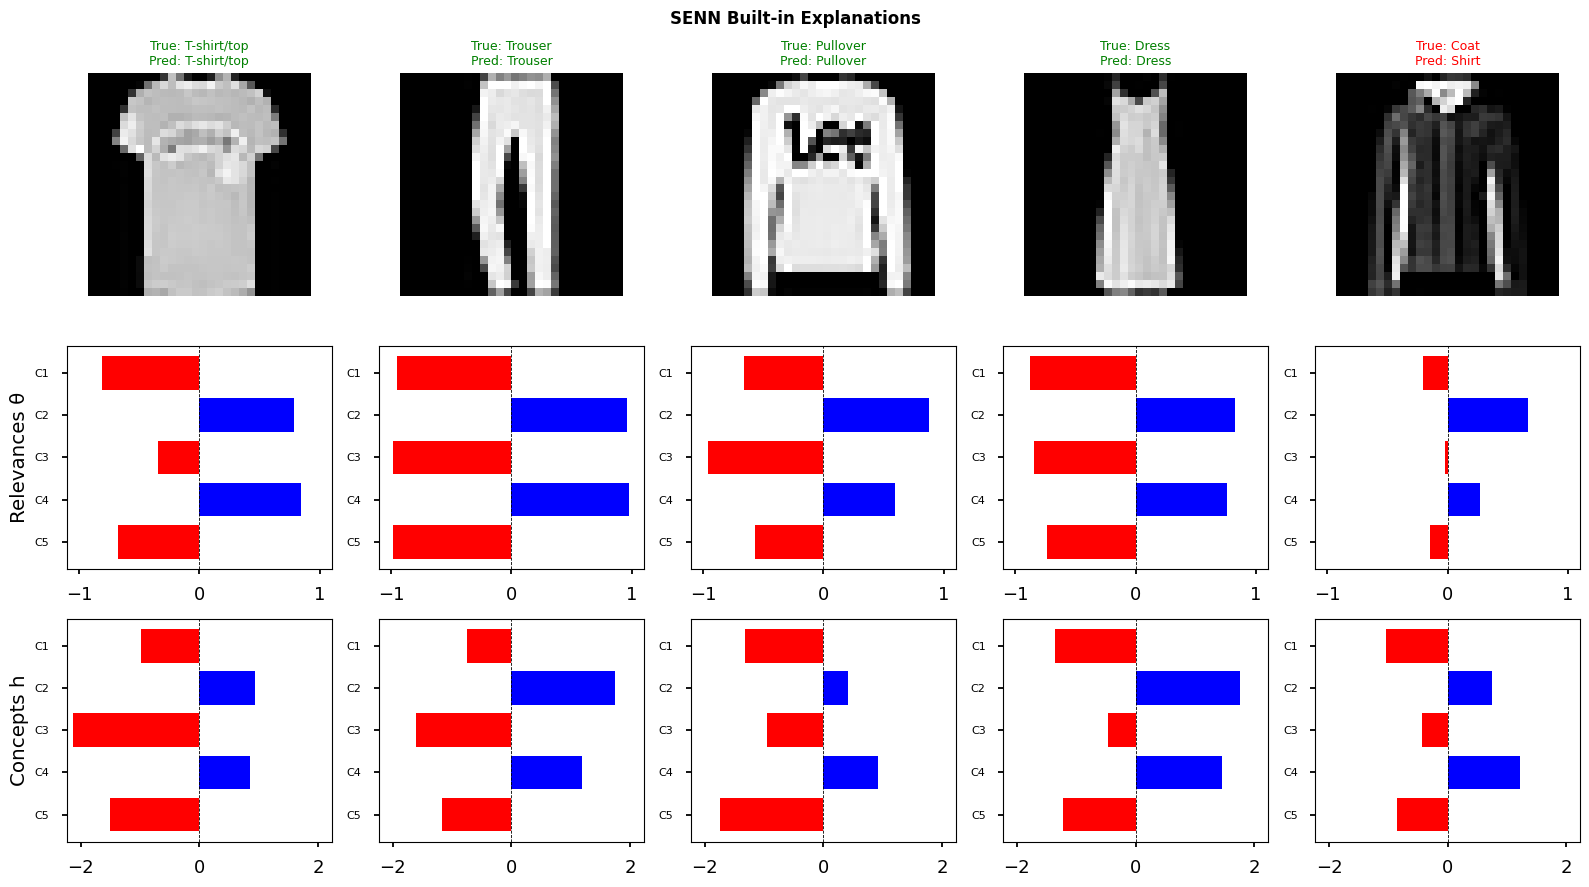

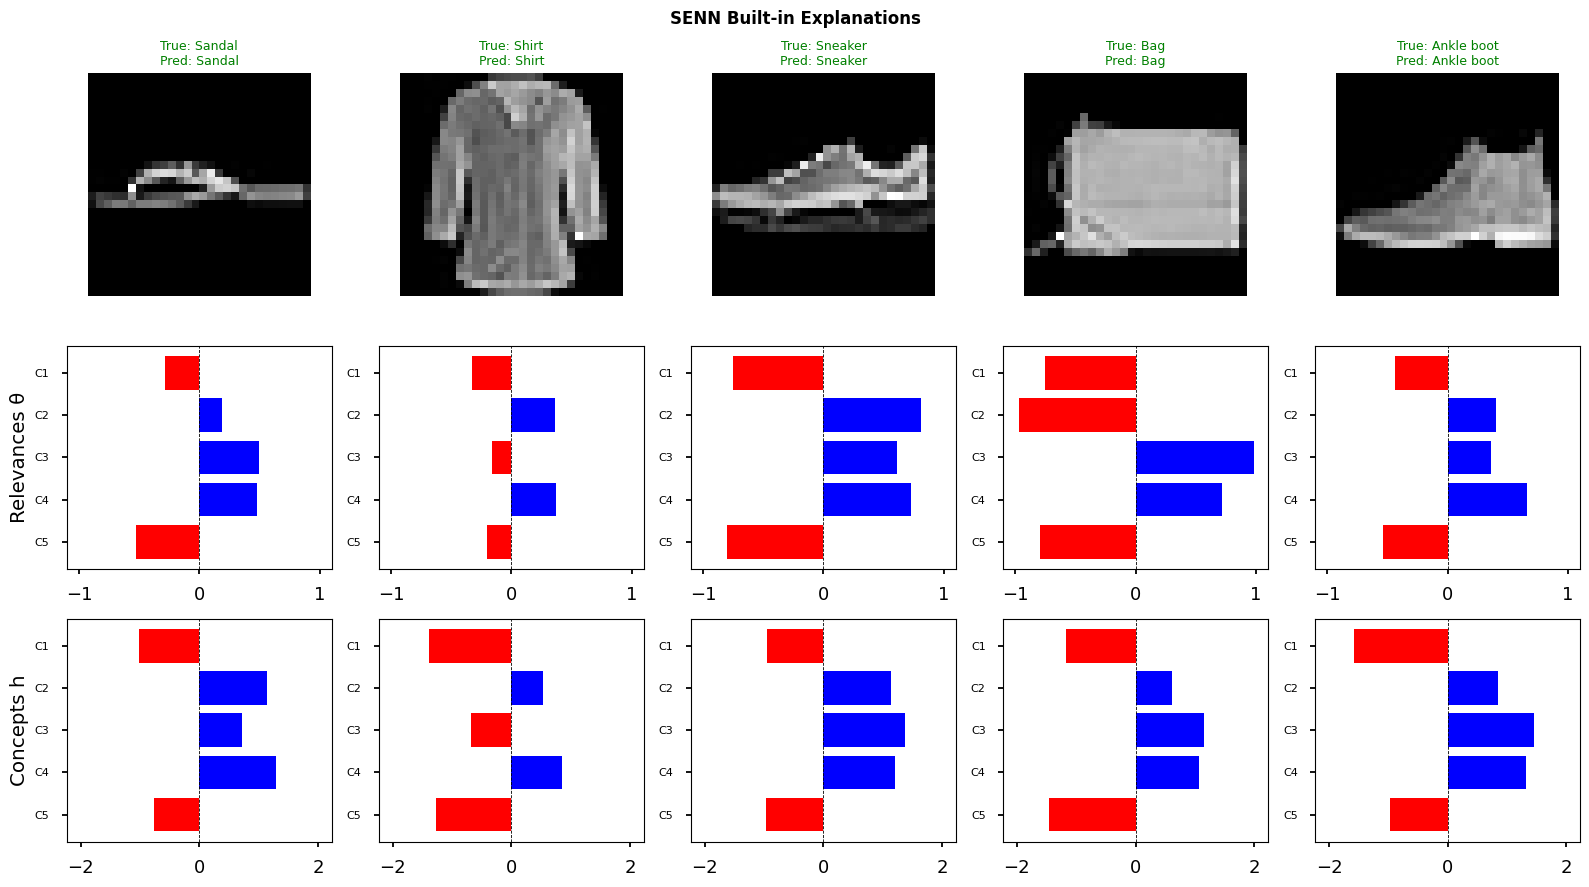

In [11]:
# ─── SENN explanations (live — single forward pass) ──────────────────────────
model.eval()
with torch.no_grad():
    y_pred_pc, (concepts_pc, relevances_pc), _ = model(per_class_imgs)
targets_pc = y_pred_pc.argmax(1)


def plot_senn_explanations(images, y_pred, concepts, relevances, class_names, ncols=5):
    n = len(images)
    pred_idx = y_pred.argmax(1)
    num_concepts = concepts.shape[1]
    concept_lim = max(abs(concepts.min().item()), abs(concepts.max().item())) + 0.1
    y_labels = [f'C{j+1}' for j in range(num_concepts - 1, -1, -1)]
    for g in range((n + ncols - 1) // ncols):
        start = g * ncols
        end = min(start + ncols, n)
        nc = end - start
        fig, axes = plt.subplots(3, nc, figsize=(3.2 * nc, 9))
        if nc == 1:
            axes = axes[:, np.newaxis]
        for col, idx in enumerate(range(start, end)):
            true_lab = class_names[idx] if idx < len(class_names) else '?'
            pred_lab = class_names[pred_idx[idx].item()]
            color = 'green' if true_lab == pred_lab else 'red'
            axes[0, col].imshow(images[idx].squeeze().cpu(), cmap='gray')
            axes[0, col].set_title(f'True: {true_lab}\nPred: {pred_lab}', fontsize=9, color=color)
            axes[0, col].axis('off')
            rs = relevances[idx, :, pred_idx[idx].item()].cpu()
            colors_r = ['b' if v > 0 else 'r' for v in rs.tolist()][::-1]
            axes[1, col].barh(np.arange(num_concepts), np.flip(rs.numpy()), color=colors_r)
            axes[1, col].set_yticks(np.arange(num_concepts))
            axes[1, col].set_yticklabels(y_labels, fontsize=8)
            axes[1, col].set_xlim(-1.1, 1.1)
            axes[1, col].axvline(0, color='k', lw=0.6, ls='--')
            if col == 0:
                axes[1, col].set_ylabel('Relevances \u03b8')
            cs = concepts[idx].flatten().cpu()
            colors_c = ['b' if v > 0 else 'r' for v in cs.tolist()][::-1]
            axes[2, col].barh(np.arange(num_concepts), np.flip(cs.numpy()), color=colors_c)
            axes[2, col].set_yticks(np.arange(num_concepts))
            axes[2, col].set_yticklabels(y_labels, fontsize=8)
            axes[2, col].set_xlim(-concept_lim, concept_lim)
            axes[2, col].axvline(0, color='k', lw=0.6, ls='--')
            if col == 0:
                axes[2, col].set_ylabel('Concepts h')
        plt.suptitle('SENN Built-in Explanations', fontweight='bold')
        plt.tight_layout()
        plt.show()

plot_senn_explanations(per_class_imgs, y_pred_pc, concepts_pc, relevances_pc, FASHION_MNIST_CLASSES)

---
## 4. Integrated Gradients — saliency maps

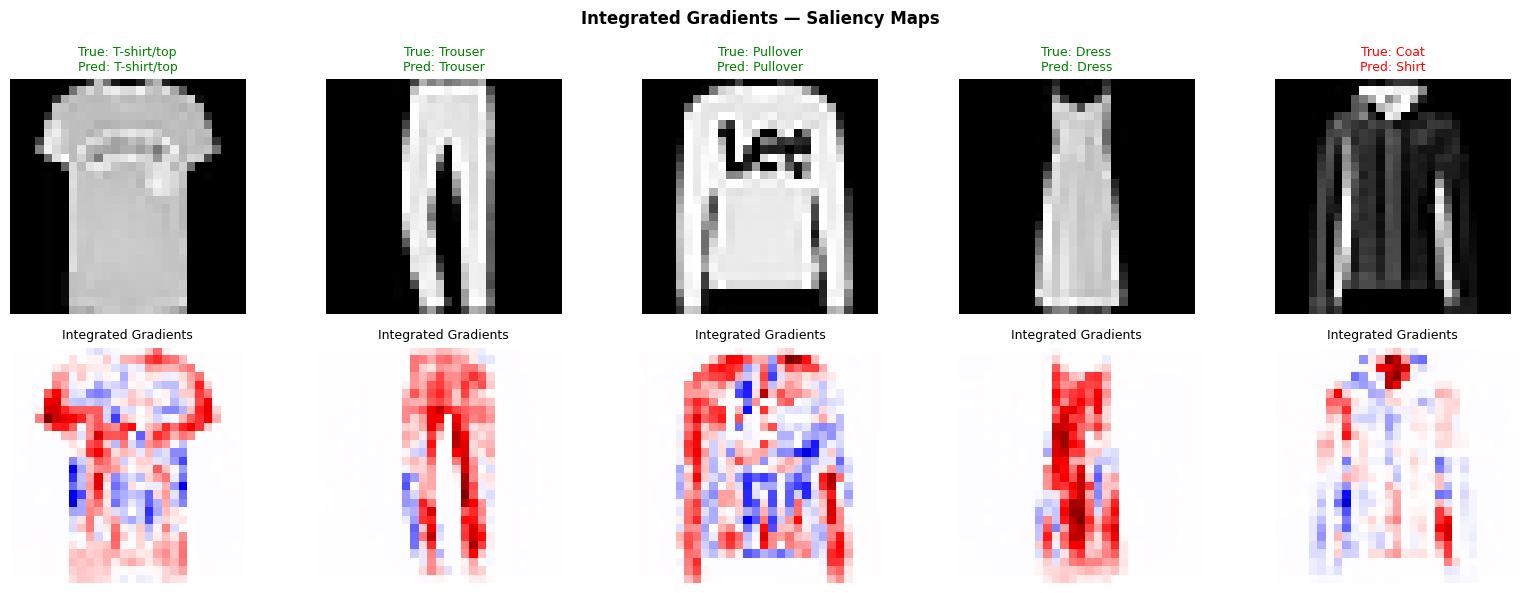

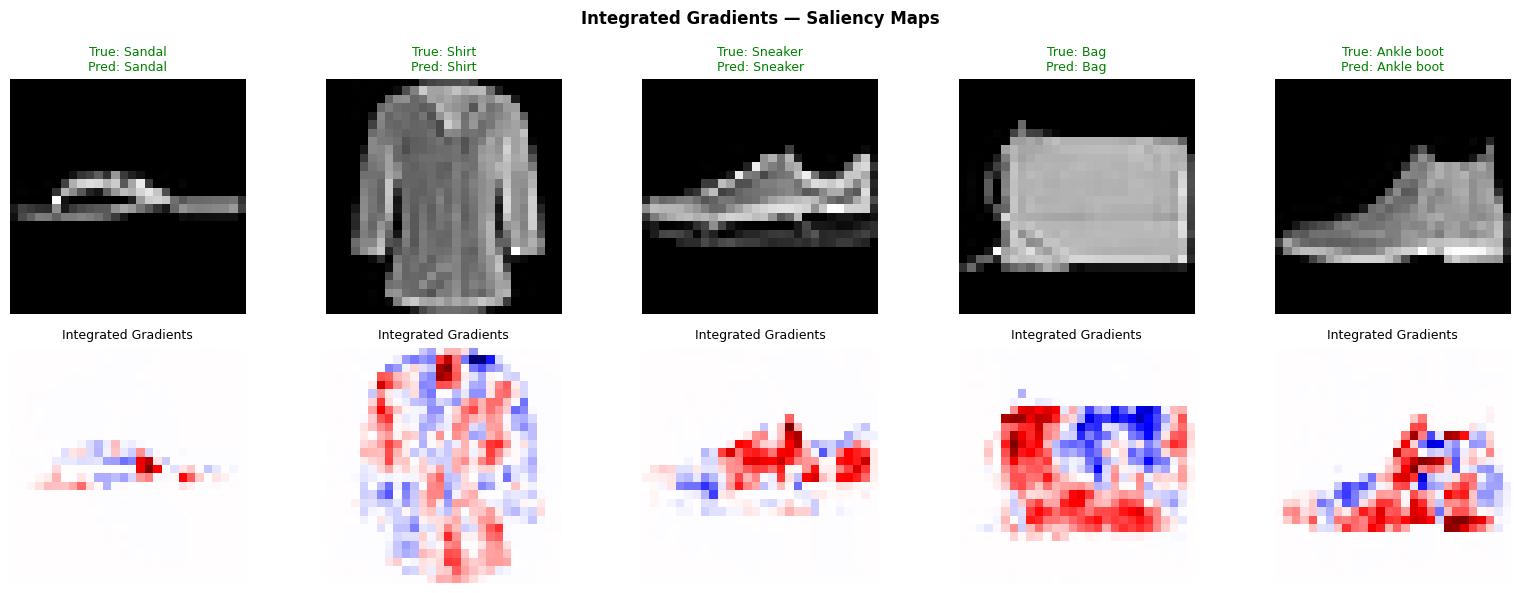

In [12]:
# ─── Visualise IG saliency maps (from pre-computed attributions) ─────────────
def plot_saliency_maps(images, attributions, pred_labels, true_labels,
                       class_names, method_name, ncols=5):
    n = len(images)
    for g in range((n + ncols - 1) // ncols):
        start = g * ncols
        end = min(start + ncols, n)
        nc = end - start
        fig, axes = plt.subplots(2, nc, figsize=(3.2 * nc, 6))
        if nc == 1:
            axes = axes[:, np.newaxis]
        for col, idx in enumerate(range(start, end)):
            true_lab = class_names[true_labels[idx].item()]
            pred_lab = class_names[pred_labels[idx].item()]
            color = 'green' if true_lab == pred_lab else 'red'
            axes[0, col].imshow(images[idx].squeeze().cpu(), cmap='gray')
            axes[0, col].set_title(f'True: {true_lab}\nPred: {pred_lab}', fontsize=9, color=color)
            axes[0, col].axis('off')
            attr = attributions[idx].sum(dim=0).cpu().numpy()
            abs_max = max(abs(attr.min()), abs(attr.max())) + 1e-8
            axes[1, col].imshow(attr, cmap='seismic', vmin=-abs_max, vmax=abs_max)
            axes[1, col].set_title(method_name, fontsize=9)
            axes[1, col].axis('off')
        plt.suptitle(f'{method_name} — Saliency Maps', fontweight='bold')
        plt.tight_layout()
        plt.show()

plot_saliency_maps(per_class_imgs, ig_attr_pc, targets_pc, per_class_labs,
                   FASHION_MNIST_CLASSES, 'Integrated Gradients')

---
## 5. LIME — saliency maps

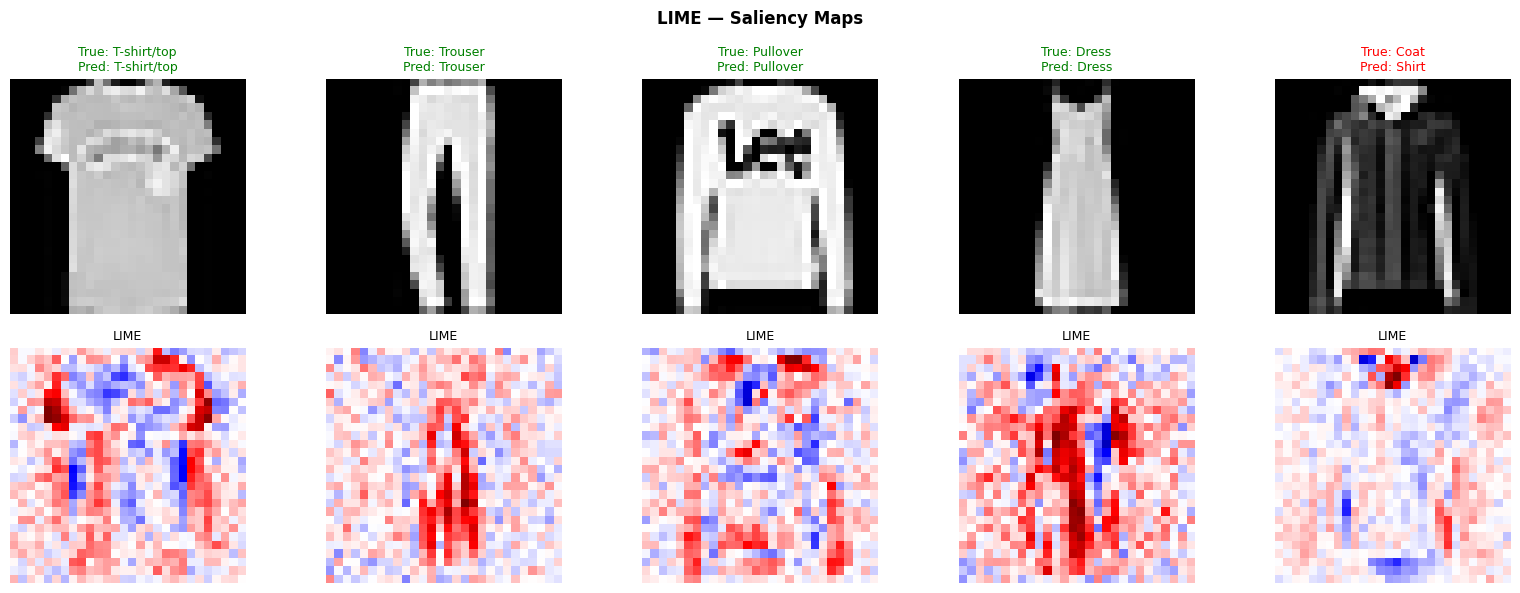

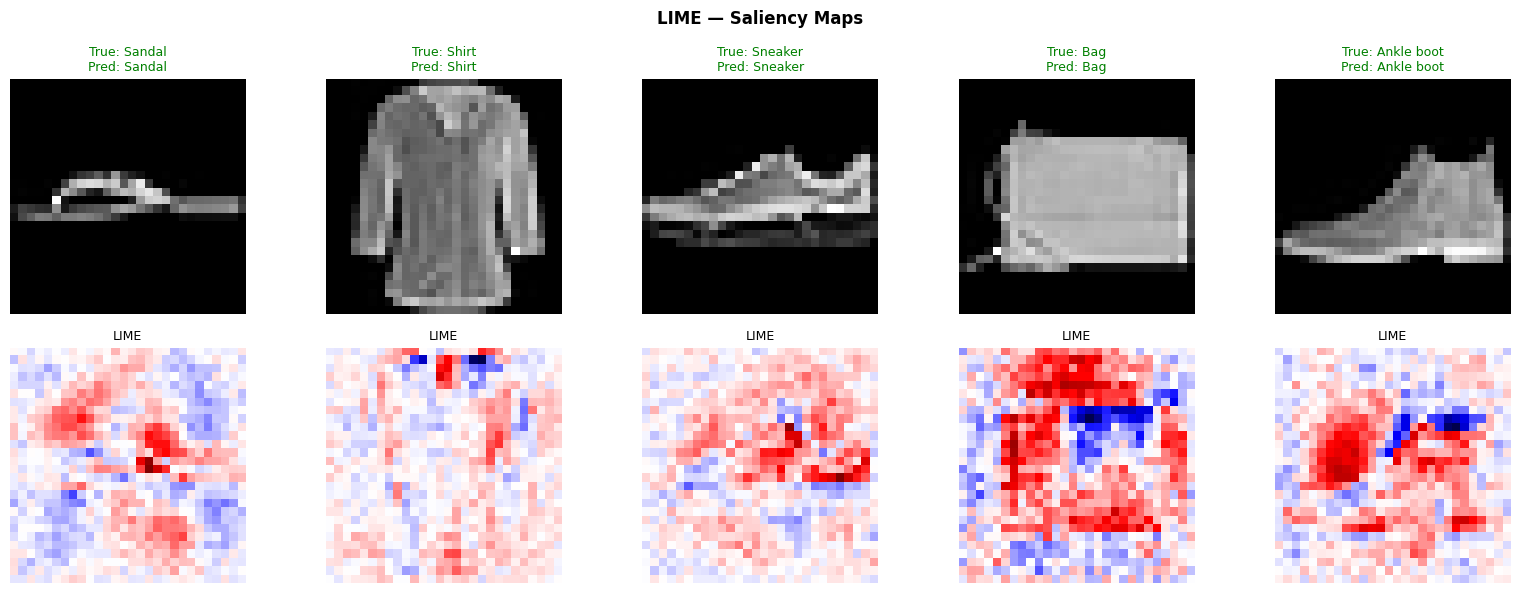

In [13]:
# ─── Visualise LIME saliency maps (from pre-computed attributions) ────────────
plot_saliency_maps(per_class_imgs, lime_attr_pc, targets_pc, per_class_labs,
                   FASHION_MNIST_CLASSES, 'LIME')

---
## 6. Side-by-Side Comparison

For each class: original image | SENN relevance bars | IG heatmap | LIME heatmap.

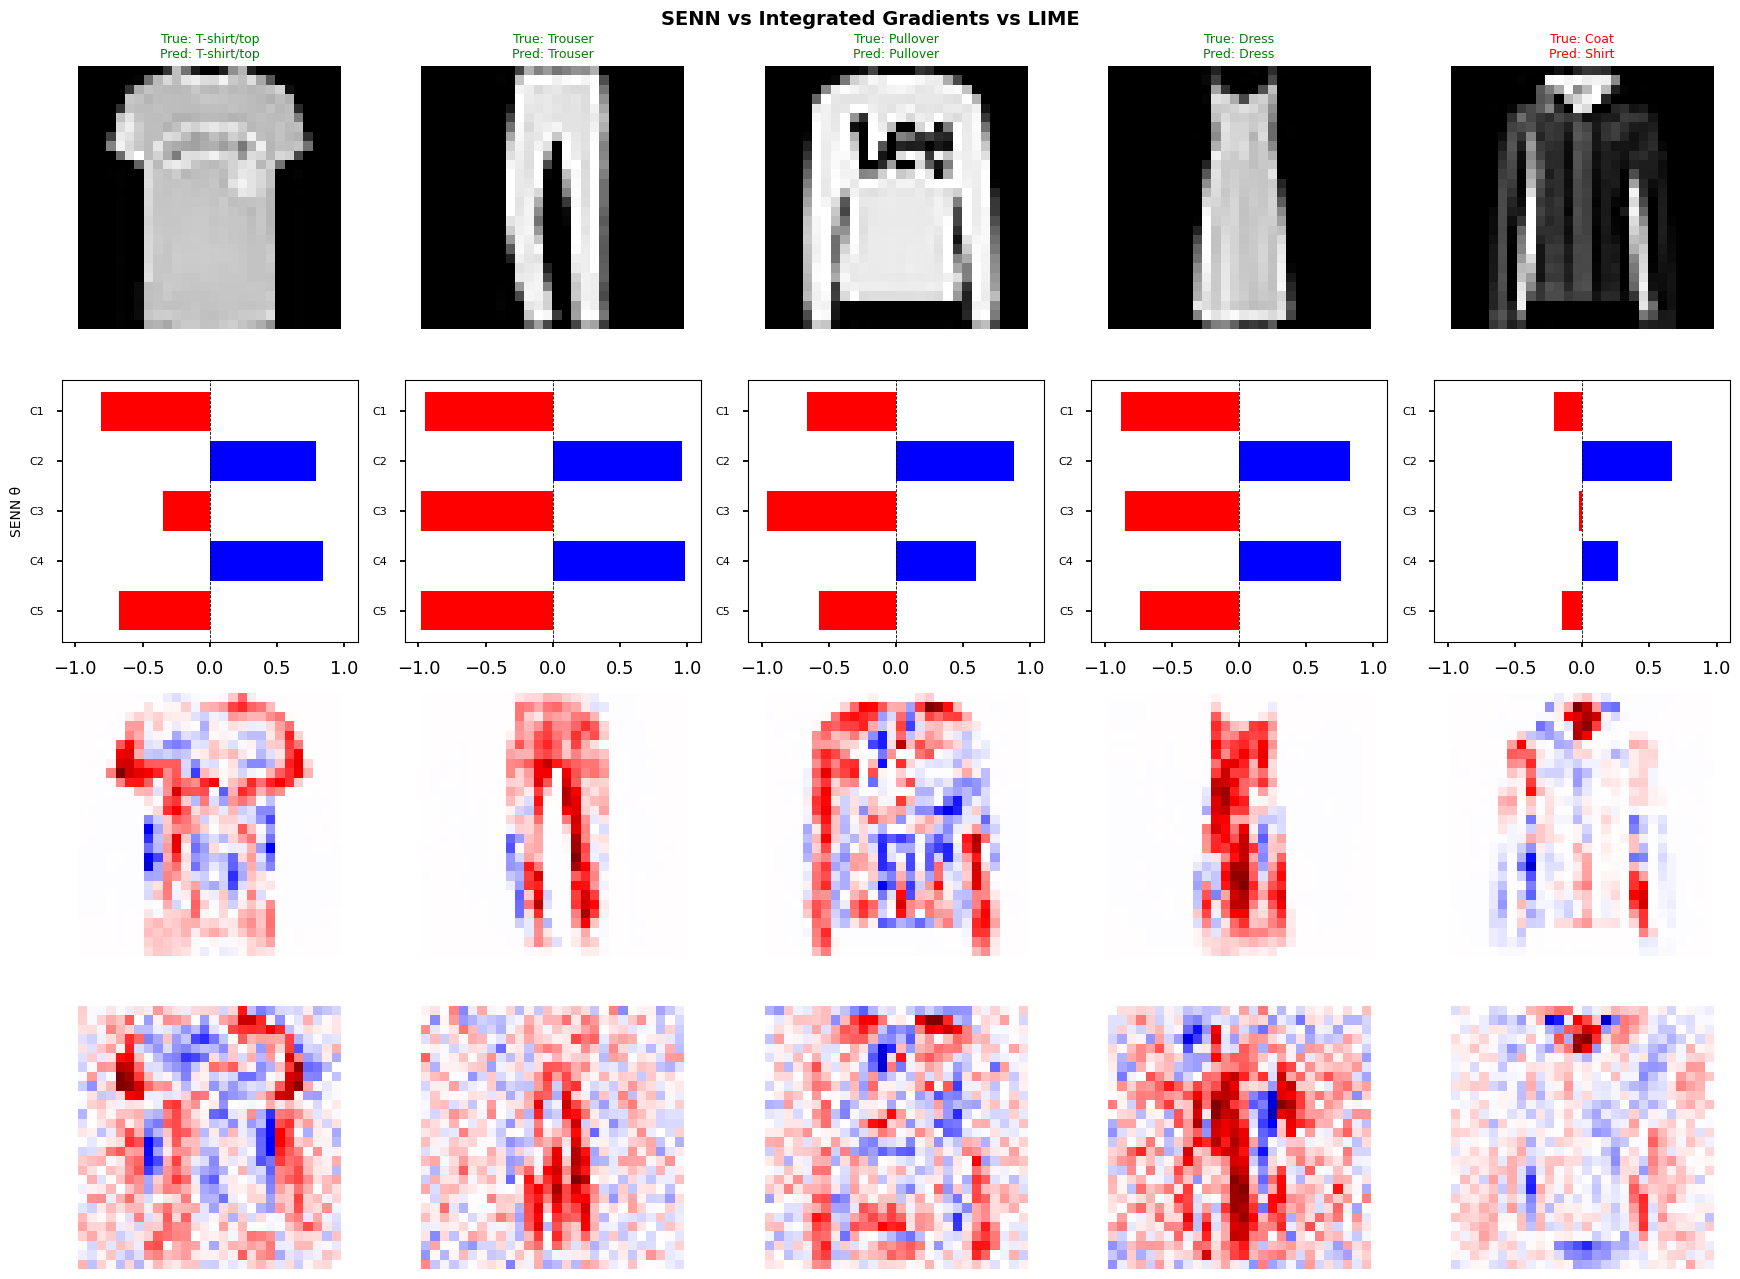

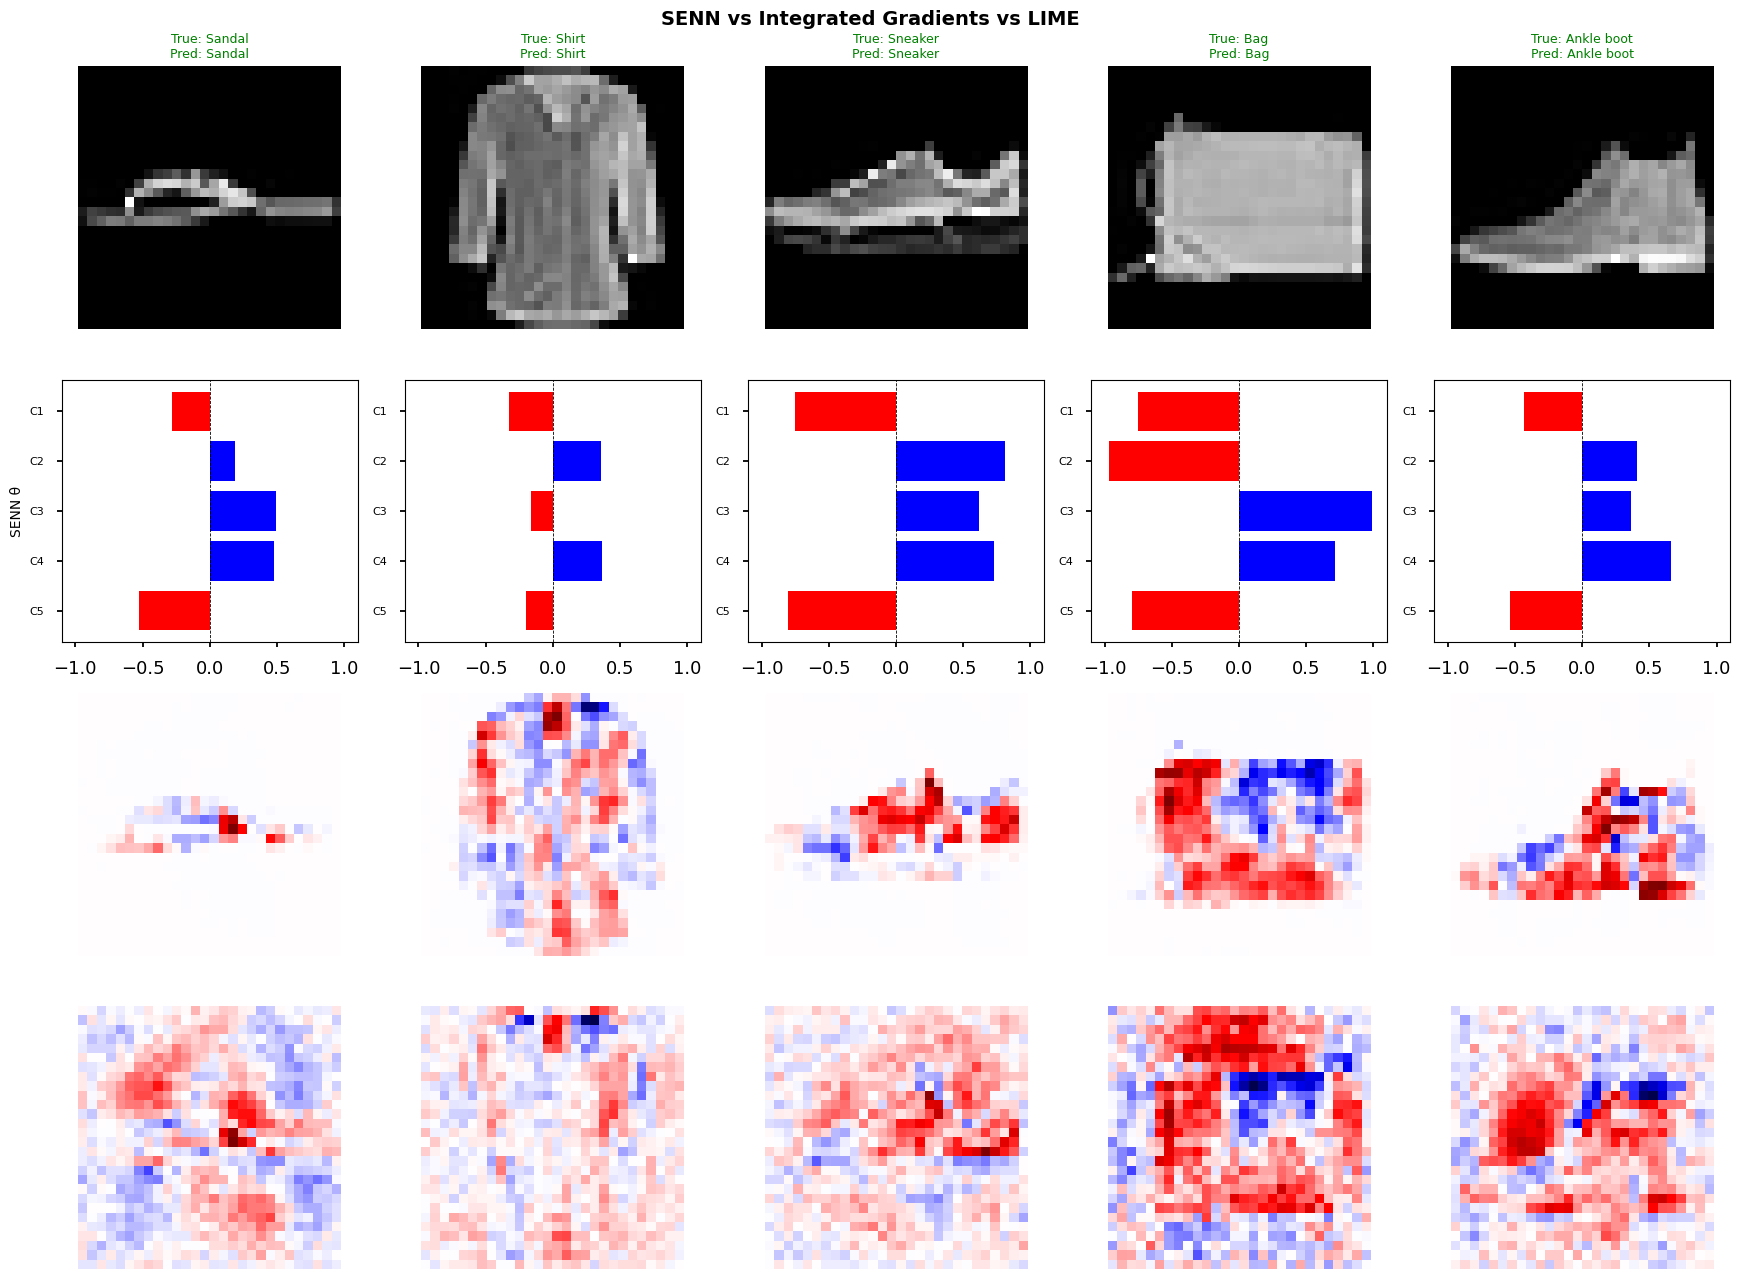

In [14]:
# ─── Three-way comparison ────────────────────────────────────────────────────
def plot_three_way_comparison(images, true_labels, y_pred, concepts, relevances,
                              ig_attrs, lime_attrs, class_names, ncols=5):
    n = len(images)
    pred_idx = y_pred.argmax(1)
    num_concepts = concepts.shape[1]
    y_labels = [f'C{j+1}' for j in range(num_concepts - 1, -1, -1)]
    for g in range((n + ncols - 1) // ncols):
        start = g * ncols
        end = min(start + ncols, n)
        nc = end - start
        fig, axes = plt.subplots(4, nc, figsize=(3.5 * nc, 13))
        if nc == 1:
            axes = axes[:, np.newaxis]
        for col, idx in enumerate(range(start, end)):
            true_lab = class_names[true_labels[idx].item()]
            pred_lab = class_names[pred_idx[idx].item()]
            color = 'green' if true_lab == pred_lab else 'red'
            # Row 0 — image
            axes[0, col].imshow(images[idx].squeeze().cpu(), cmap='gray')
            axes[0, col].set_title(f'True: {true_lab}\nPred: {pred_lab}', fontsize=9, color=color)
            axes[0, col].axis('off')
            # Row 1 — SENN relevances
            rs = relevances[idx, :, pred_idx[idx].item()].cpu()
            colors_r = ['b' if v > 0 else 'r' for v in rs.tolist()][::-1]
            axes[1, col].barh(np.arange(num_concepts), np.flip(rs.numpy()), color=colors_r)
            axes[1, col].set_yticks(np.arange(num_concepts))
            axes[1, col].set_yticklabels(y_labels, fontsize=8)
            axes[1, col].set_xlim(-1.1, 1.1)
            axes[1, col].axvline(0, color='k', lw=0.6, ls='--')
            if col == 0:
                axes[1, col].set_ylabel('SENN \u03b8', fontsize=10)
            # Row 2 — IG
            ig_map = ig_attrs[idx].sum(dim=0).cpu().numpy()
            abs_max_ig = max(abs(ig_map.min()), abs(ig_map.max())) + 1e-8
            axes[2, col].imshow(ig_map, cmap='seismic', vmin=-abs_max_ig, vmax=abs_max_ig)
            axes[2, col].axis('off')
            if col == 0:
                axes[2, col].set_ylabel('Int. Grad.', fontsize=10)
            # Row 3 — LIME
            lime_map = lime_attrs[idx].sum(dim=0).cpu().numpy()
            abs_max_lm = max(abs(lime_map.min()), abs(lime_map.max())) + 1e-8
            axes[3, col].imshow(lime_map, cmap='seismic', vmin=-abs_max_lm, vmax=abs_max_lm)
            axes[3, col].axis('off')
            if col == 0:
                axes[3, col].set_ylabel('LIME', fontsize=10)
        plt.suptitle('SENN vs Integrated Gradients vs LIME', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

plot_three_way_comparison(
    per_class_imgs, per_class_labs,
    y_pred_pc, concepts_pc, relevances_pc,
    ig_attr_pc, lime_attr_pc,
    FASHION_MNIST_CLASSES
)

---
## 7. Computational Cost Comparison

Timing from the pre-computed runs (wall-clock, full test set).

In [15]:
# ─── Computational cost (from saved meta) ────────────────────────────────────
# SENN cost: single forward pass on the test set for reference
import time
model.eval()
n_senn = 0
t0 = time.perf_counter()
with torch.no_grad():
    for x, _ in test_loader:
        _ = model(x.float().to(DEVICE))
        n_senn += len(x)
senn_time_per_sample = (time.perf_counter() - t0) / n_senn

ig_time_per_sample   = ig_meta['time_per_sample_s']
lime_time_per_sample = lime_meta['time_per_sample_s']

print(f'{"Method":<25} {"s / sample":>12} {"Fwd passes":>14}')
print('\u2500' * 55)
print(f'{"SENN (built-in)":<25} {senn_time_per_sample:>12.5f} {"1":>14}')
print(f'{"Integrated Gradients":<25} {ig_time_per_sample:>12.5f} {"~" + str(ig_meta.get("n_steps", 50)):>14}')
print(f'{"LIME":<25} {lime_time_per_sample:>12.5f} {"~" + str(lime_meta.get("n_lime_samples", 500)):>14}')

Method                      s / sample     Fwd passes
───────────────────────────────────────────────────────
SENN (built-in)                0.00029              1
Integrated Gradients           0.00112            ~50
LIME                           4.99774          ~2000


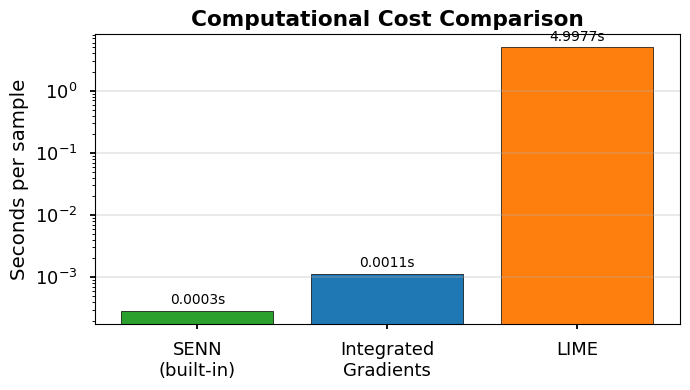

In [16]:
# ─── Cost bar chart ──────────────────────────────────────────────────────────
methods = ['SENN\n(built-in)', 'Integrated\nGradients', 'LIME']
times = [senn_time_per_sample, ig_time_per_sample, lime_time_per_sample]
colors = ['#2ca02c', '#1f77b4', '#ff7f0e']

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(methods, times, color=colors, edgecolor='black', linewidth=0.5)
ax.set_ylabel('Seconds per sample')
ax.set_title('Computational Cost Comparison', fontweight='bold')
for bar, t in zip(bars, times):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.15,
            f'{t:.4f}s', ha='center', va='bottom', fontsize=10)
ax.set_yscale('log')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 8. Faithfulness: Relative Ablation Test (Top vs Random)

Per valutare la *faithfulness* (fedeltà) delle spiegazioni, misuriamo quanto cala la confidenza del modello (Confidence Drop) quando rimuoviamo le feature ritenute più importanti.

Tuttavia, confrontare direttamente l'ablation dei **concetti latenti** (SENN) con l'ablation dei **pixel grezzi** (LIME/IG) genera un problema di discrepanza metodologica (effetto "Mele con Pere"). Oscurare i pixel inserendo il valore di background (nero normalizzato, $-0.8102$) crea immagini innaturali con artefatti visivi. Questo genera dati **Out-of-Distribution (OOD)** che confondono la rete neurale: la confidenza crolla non solo perché manca un'informazione vitale, ma perché l'immagine risulta "aliena". La SENN, azzerando i concetti nel suo spazio latente, non soffre di questo problema.

Per garantire un confronto *fair* (equo), abbiamo introdotto una **Metrica Relativa**:
$\text{Relative Drop} = \text{Drop}(\text{Top Features}) - \text{Drop}(\text{Random Features})$

In questo modo, filtriamo il "rumore" causato dall'effetto OOD:
* **Per LIME e IG:** Confrontiamo il calo di confidenza causato dall'oscuramento del Top-20% dei pixel rispetto all'oscuramento di un 20% di pixel casuali.
* **Per la SENN:** Confrontiamo il calo di confidenza causato dall'azzeramento del Top-1 concept rispetto a un concetto scelto casualmente.



In [26]:
# ─── SENN Relative Ablation Test (Top vs Random Concept) ─────────────────────
model = trainer.model
model.eval()

all_senn_drop_top = []
all_senn_drop_rand = []
all_senn_drop_relative = []

with torch.no_grad():
    for x, y in trainer.test_loader:
        x = x.float().to(device)
        y = y.long().to(device)

        y_pred, (concepts, relevances), _ = model(x)
        preds = y_pred.argmax(dim=1)
        
        probs_orig = torch.softmax(y_pred, dim=1)
        conf_orig = probs_orig[torch.arange(len(preds)), preds]

        # Creiamo due copie dei concetti: una per il Top, una per il Random
        concepts_abl_top = concepts.clone()
        concepts_abl_rand = concepts.clone()

        for i in range(len(x)):
            # 1. Ablation TOP: Azzeriamo il concetto con l'importanza (theta) assoluta maggiore
            rel_for_pred = relevances[i, :, preds[i].item()].abs()
            top_concept = rel_for_pred.argmax().item()
            concepts_abl_top[i, top_concept, :] = 0.0
            
            # 2. Ablation RANDOM: Azzeriamo un concetto a caso
            rand_concept = torch.randint(0, concepts.shape[1], (1,)).item()
            concepts_abl_rand[i, rand_concept, :] = 0.0

        # Ricalcoliamo le confidenze per entrambe le versioni perturbate
        y_pred_top = model.aggregator(concepts_abl_top, relevances)
        conf_top = torch.softmax(y_pred_top, dim=1)[torch.arange(len(preds)), preds]
        
        y_pred_rand = model.aggregator(concepts_abl_rand, relevances)
        conf_rand = torch.softmax(y_pred_rand, dim=1)[torch.arange(len(preds)), preds]

        # Calcoliamo i Drop Assoluti e il Vantaggio Relativo
        drop_top = (conf_orig - conf_top).cpu().numpy()
        drop_rand = (conf_orig - conf_rand).cpu().numpy()
        drop_relative = drop_top - drop_rand

        all_senn_drop_top.extend(drop_top)
        all_senn_drop_rand.extend(drop_rand)
        all_senn_drop_relative.extend(drop_relative)

# Convertiamo in array numpy per comodità
all_senn_drop_top = np.array(all_senn_drop_top)
all_senn_drop_rand = np.array(all_senn_drop_rand)
all_senn_drop_relative = np.array(all_senn_drop_relative)

print(f"SENN Top Concept Drop    : {all_senn_drop_top.mean():.4f}")
print(f"SENN Random Concept Drop : {all_senn_drop_rand.mean():.4f}")
print(f"SENN Relative Drop       : {all_senn_drop_relative.mean():.4f}")

SENN Top Concept Drop    : 0.0354
SENN Random Concept Drop : 0.0462
SENN Relative Drop       : -0.0108


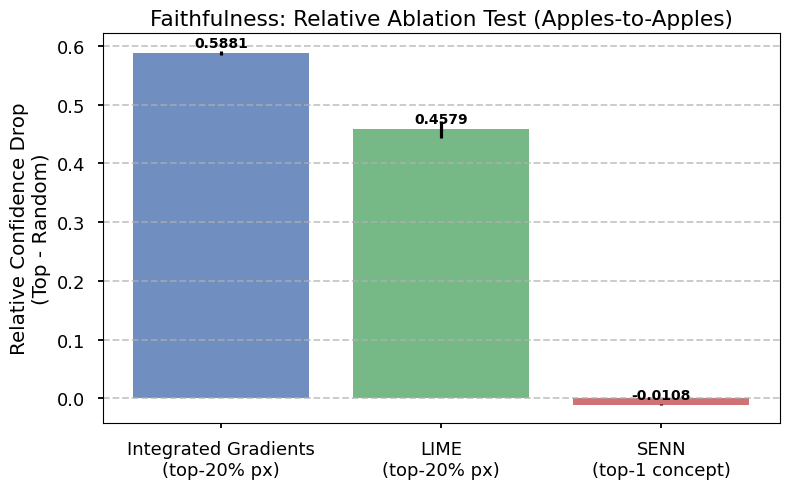


--- Riepilogo metriche di Ablation ---
              Method      Feature Type  Top Drop (Abs)  Rand Drop (Abs)  Relative Drop
                SENN Concepts (Latent)          0.0354           0.0462        -0.0108
Integrated Gradients      Pixels (Raw)          0.6693           0.0812         0.5881
                LIME      Pixels (Raw)          0.5391           0.0811         0.4579


In [27]:
import matplotlib.pyplot as plt
import pandas as pd

# ─── Plotting Relative Confidence Drop ───────────────────────────────────────
labels = ['Integrated Gradients\n(top-20% px)', 'LIME\n(top-20% px)', 'SENN\n(top-1 concept)']
# Usiamo la metrica RELATIVA (Vantaggio reale)
means = [ig_drop_relative.mean(), lime_drop_relative.mean(), all_senn_drop_relative.mean()]

# Calcolo standard error
stds = [
    ig_drop_relative.std() / np.sqrt(len(ig_drop_relative)), 
    lime_drop_relative.std() / np.sqrt(len(lime_drop_relative)), 
    all_senn_drop_relative.std() / np.sqrt(len(all_senn_drop_relative))
]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, means, yerr=stds, capsize=5, color=['#4C72B0', '#55A868', '#C44E52'], alpha=0.8)

# Titoli aggiornati
ax.set_ylabel('Relative Confidence Drop\n(Top - Random)')
ax.set_title('Faithfulness: Relative Ablation Test (Apples-to-Apples)')
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Etichette di valore sulle barre
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 0.005, f'{yval:.4f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# ─── Tabella Finale Riepilogativa ────────────────────────────────────────────
summary = pd.DataFrame({
    'Method': ['SENN', 'Integrated Gradients', 'LIME'],
    'Feature Type': ['Concepts (Latent)', 'Pixels (Raw)', 'Pixels (Raw)'],
    'Top Drop (Abs)': [all_senn_drop_top.mean(), ig_drop_top.mean(), lime_drop_top.mean()],
    'Rand Drop (Abs)': [all_senn_drop_rand.mean(), ig_drop_rand.mean(), lime_drop_rand.mean()],
    'Relative Drop': [all_senn_drop_relative.mean(), ig_drop_relative.mean(), lime_drop_relative.mean()]
})

summary = summary.round(4)
print("\n--- Riepilogo metriche di Ablation ---")
print(summary.to_string(index=False))

In [ ]:
# ─── Distribuzione dei Relative Drops ────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)

data = [
    (ig_drop_relative,          'Integrated Gradients\n(top-20% px)',  '#4C72B0', 10000),
    (lime_drop_relative,        'LIME\n(top-20% px)',                  '#55A868', 600),
    (all_senn_drop_relative,    'SENN\n(top-1 concept)',               '#C44E52', 10000),
]

for ax, (arr, label, color, n) in zip(axes, data):
    ax.hist(arr, bins=50, color=color, alpha=0.75, edgecolor='white', linewidth=0.5)
    ax.axvline(arr.mean(), color='black', linestyle='--', linewidth=1.5, label=f'mean={arr.mean():.3f}')
    ax.axvline(0, color='gray', linestyle=':', linewidth=1)
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('Relative Drop (Top − Random)')
    ax.set_ylabel('Count')
    stats_text = (f'N     = {n}\n'
                  f'mean  = {arr.mean():.4f}\n'
                  f'std   = {arr.std():.4f}\n'
                  f'min   = {arr.min():.4f}\n'
                  f'max   = {arr.max():.4f}')
    ax.text(0.97, 0.97, stats_text, transform=ax.transAxes, fontsize=8,
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    ax.legend(fontsize=8)

plt.suptitle('Distribuzione dei Relative Confidence Drops', fontweight='bold')
plt.tight_layout()
plt.show()

In [30]:
# ─── Relative Ablation results ────────────────────────────────────────────────
print(f'{"Method":<30} {"Mean Rel. Drop":>15} {"Std":>10} {"N samples":>10}')
print('─' * 68)
print(f'{"Integrated Gradients (20% px)":<30} {ig_drop_relative.mean():>15.4f} {ig_drop_relative.std():>10.4f} {len(ig_drop_relative):>10}')
print(f'{"LIME (20% px)":<30} {lime_drop_relative.mean():>15.4f} {lime_drop_relative.std():>10.4f} {len(lime_drop_relative):>10}')
print(f'{"SENN (top-1 concept)":<30} {all_senn_drop_relative.mean():>15.4f} {all_senn_drop_relative.std():>10.4f} {len(all_senn_drop_relative):>10}')

Method                          Mean Rel. Drop        Std  N samples
────────────────────────────────────────────────────────────────────
Integrated Gradients (20% px)           0.5881     0.3279      10000
LIME (20% px)                           0.4579     0.3477        600
SENN (top-1 concept)                   -0.0108     0.0651      10000


In [ ]:
# ─── Distribution of Relative Drops (histogram per method) ───────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)

data = [
    (ig_drop_relative,        'Integrated Gradients\n(top-20% pixels)', '#4C72B0'),
    (lime_drop_relative,      'LIME\n(top-20% pixels)',                  '#55A868'),
    (all_senn_drop_relative,  'SENN\n(top-1 concept by |θ|)',            '#C44E52'),
]

for ax, (arr, label, color) in zip(axes, data):
    ax.hist(arr, bins=50, color=color, alpha=0.75, edgecolor='white', linewidth=0.4)
    ax.axvline(arr.mean(), color='black', linestyle='--', linewidth=1.5, label=f'mean = {arr.mean():.3f}')
    ax.axvline(0, color='gray', linestyle=':', linewidth=1.0, label='random baseline (0)')
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('Relative Drop (Top − Random)')
    ax.set_ylabel('Count')
    stats_text = (
        f'N     = {len(arr)}\n'
        f'mean  = {arr.mean():.4f}\n'
        f'std   = {arr.std():.4f}\n'
        f'min   = {arr.min():.4f}\n'
        f'max   = {arr.max():.4f}'
    )
    ax.text(0.97, 0.97, stats_text, transform=ax.transAxes, fontsize=8,
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))
    ax.legend(fontsize=8)

plt.suptitle('Distribution of Relative Confidence Drops across Methods', fontweight='bold')
plt.tight_layout()
plt.show()

---
### 8b. Faithfulness: Spearman Correlation (Importance Rank vs Actual Drop)

A more principled faithfulness test — directly motivated by the paper — measures the
**correlation** between the estimated importance of each feature and the actual confidence
drop when that feature is removed.

- **SENN:** for each sample, ablate each of the 5 concepts one at a time → 5 actual drops.
  Compute Spearman ρ between `|hᵢ·θᵢ|` (estimated importance) and the 5 drops.
- **IG / LIME:** split pixels into 5 quintiles by `|attribution|`, ablate each quintile
  separately → 5 actual drops. Compute Spearman ρ between mean attribution in each quintile
  and the 5 drops.
- **Random baseline:** same quintile procedure but with shuffled (random) attributions.
  Expected ρ ≈ 0 because random scores carry no true importance information.

In [ ]:
from scipy.stats import spearmanr

# ─── SENN Spearman: |h·θ| vs actual per-concept ablation drop ────────────────
# For each sample: ablate each of the 5 concepts individually via the aggregator
# (no image re-encoding needed — fast), then correlate with |hᵢ·θᵢ|.

model.eval()
senn_spearman = []

with torch.no_grad():
    for x, _ in trainer.test_loader:
        x = x.float().to(DEVICE)
        y_pred, (concepts, relevances), _ = model(x)
        preds  = y_pred.argmax(dim=1)
        probs  = torch.softmax(y_pred, dim=1)
        conf_orig = probs[torch.arange(len(preds)), preds]  # (batch,)

        num_concepts = concepts.shape[1]

        for i in range(len(x)):
            h_i    = concepts[i].squeeze().cpu().numpy()          # (C,)
            th_i   = relevances[i, :, preds[i].item()].cpu().numpy()  # (C,)
            estimated = np.abs(h_i * th_i)                        # |hᵢ·θᵢ|

            drops = []
            for j in range(num_concepts):
                c_abl = concepts[i].clone().unsqueeze(0)   # (1, C, d)
                c_abl[0, j, :] = 0.0
                y_abl = model.aggregator(c_abl, relevances[i].unsqueeze(0))
                conf_abl = torch.softmax(y_abl, dim=1)[0, preds[i]].item()
                drops.append(conf_orig[i].item() - conf_abl)

            drops = np.array(drops)
            # Only compute correlation when there is variance in both arrays
            if drops.std() > 1e-8 and estimated.std() > 1e-8:
                rho, _ = spearmanr(estimated, drops)
                senn_spearman.append(rho)

senn_spearman = np.array(senn_spearman)
print(f"SENN Spearman ρ (|h·θ| vs actual drop per concept)")
print(f"  N={len(senn_spearman):>6},  mean={senn_spearman.mean():.4f},  std={senn_spearman.std():.4f}")

In [ ]:
# ─── IG / LIME Spearman + correct Random baseline (quintile-based) ────────────
#
# Why the earlier random baseline was WRONG:
#   The previous code sampled d_top and d_rand independently from the IG drop
#   distributions.  Because IG is faithful, E[ig_drop_top] >> E[ig_drop_rand],
#   so the mean of their difference ≈ the IG relative drop itself — not 0.
#
# Correct approach — shuffle the attribution map per image:
#   Shuffled "top-20%" ≈ any random 20% → relative drop ≈ 0 by construction.
#
# For Spearman we use 5 quintiles (bins) of pixels by |attribution| to match
# SENN's 5 concepts, giving 5 (importance, drop) pairs per image.

class SENNWrapper(torch.nn.Module):
    """Thin wrapper that exposes only logits, as required for pixel ablation."""
    def __init__(self, senn_model):
        super().__init__()
        self.senn = senn_model
    def forward(self, x):
        logits, _, _ = self.senn(x)
        return logits

wrapper = SENNWrapper(model).to(DEVICE)
wrapper.eval()

FILL_VALUE = -0.8102   # normalised black pixel: (0 - 0.2860) / 0.3530
N_BINS     = 5         # match SENN's number of concepts
N_EVAL     = min(600, len(lime_labels))   # cap for speed; LIME already limited to 600
TOP_FRAC   = 0.20
N_TOP      = int(28 * 28 * TOP_FRAC)

# Collect the first N_EVAL test images in loader order (shuffle=False)
_imgs = []
for x, _ in test_loader:
    _imgs.append(x.float())
    if sum(len(b) for b in _imgs) >= N_EVAL:
        break
eval_images = torch.cat(_imgs, dim=0)[:N_EVAL]   # (N_EVAL, 1, 28, 28)

np.random.seed(42)

def quintile_spearman(images, attributions, predictions, shuffle_attr=False):
    """
    For each image: bin pixels into N_BINS quintiles by |attribution|,
    ablate each bin, measure confidence drop, compute Spearman ρ between
    mean |attribution| in the bin and the measured drop.
    Returns array of per-sample correlations.
    """
    correlations = []
    n = len(images)
    bin_size = (28 * 28) // N_BINS

    for i in range(n):
        img  = images[i].unsqueeze(0).to(DEVICE)
        pred = predictions[i].item()
        attr = attributions[i].squeeze().abs().numpy().flatten()   # (784,)

        if shuffle_attr:
            attr = np.random.permutation(attr)

        sorted_idx = np.argsort(attr)   # ascending → quintile 0 = least important

        with torch.no_grad():
            conf_orig = torch.softmax(wrapper(img), dim=1)[0, pred].item()

        bin_drops, bin_importance = [], []
        for b in range(N_BINS):
            start = b * bin_size
            end   = (b + 1) * bin_size if b < N_BINS - 1 else 784
            pix   = sorted_idx[start:end]

            img_abl = img.clone().reshape(1, -1)
            img_abl[0, pix] = FILL_VALUE
            img_abl = img_abl.reshape(1, 1, 28, 28)

            with torch.no_grad():
                conf_abl = torch.softmax(wrapper(img_abl), dim=1)[0, pred].item()

            bin_drops.append(conf_orig - conf_abl)
            bin_importance.append(attr[pix].mean())

        bin_drops      = np.array(bin_drops)
        bin_importance = np.array(bin_importance)

        if bin_drops.std() > 1e-8 and bin_importance.std() > 1e-8:
            rho, _ = spearmanr(bin_importance, bin_drops)
            correlations.append(rho)

    return np.array(correlations)


print("Computing IG quintile Spearman…")
ig_spearman   = quintile_spearman(eval_images, ig_attrs[:N_EVAL],   ig_preds[:N_EVAL])
print("Computing LIME quintile Spearman…")
lime_spearman = quintile_spearman(eval_images, lime_attrs,           lime_preds)
print("Computing Random baseline quintile Spearman…")
rand_spearman = quintile_spearman(eval_images, ig_attrs[:N_EVAL],   ig_preds[:N_EVAL],
                                  shuffle_attr=True)

print()
print(f"IG   Spearman ρ  N={len(ig_spearman):>5},  mean={ig_spearman.mean():.4f},  std={ig_spearman.std():.4f}")
print(f"LIME Spearman ρ  N={len(lime_spearman):>5},  mean={lime_spearman.mean():.4f},  std={lime_spearman.std():.4f}")
print(f"Rand Spearman ρ  N={len(rand_spearman):>5},  mean={rand_spearman.mean():.4f},  std={rand_spearman.std():.4f}  ← expected ≈0")

In [ ]:
# ─── Spearman ρ comparison bar chart ─────────────────────────────────────────
_labels = ['SENN\n(5 concepts)', 'IG\n(5 quintiles)', 'LIME\n(5 quintiles)', 'Random\nbaseline']
_means  = [senn_spearman.mean(), ig_spearman.mean(), lime_spearman.mean(), rand_spearman.mean()]
_sems   = [senn_spearman.std() / np.sqrt(len(senn_spearman)),
           ig_spearman.std()   / np.sqrt(len(ig_spearman)),
           lime_spearman.std() / np.sqrt(len(lime_spearman)),
           rand_spearman.std() / np.sqrt(len(rand_spearman))]
_colors = ['#C44E52', '#4C72B0', '#55A868', '#888888']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(_labels, _means, yerr=_sems, capsize=5,
              color=_colors, alpha=0.85, edgecolor='black', linewidth=0.5)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_ylabel('Mean Spearman ρ\n(importance rank vs actual drop)')
ax.set_title('Faithfulness: Spearman Correlation', fontweight='bold')
ax.set_ylim(-0.2, 1.05)
ax.grid(axis='y', linestyle='--', alpha=0.5)
for bar, m in zip(bars, _means):
    yoffset = 0.02 if m >= 0 else -0.05
    ax.text(bar.get_x() + bar.get_width() / 2, m + yoffset,
            f'{m:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=10)
plt.tight_layout()
plt.show()

# ─── Spearman summary table ───────────────────────────────────────────────────
spearman_df = pd.DataFrame({
    'Method':     ['SENN (5 concepts)', 'IG (5 quintiles)', 'LIME (5 quintiles)', 'Random baseline'],
    'Mean ρ':     [senn_spearman.mean(), ig_spearman.mean(), lime_spearman.mean(), rand_spearman.mean()],
    'Std ρ':      [senn_spearman.std(),  ig_spearman.std(),  lime_spearman.std(),  rand_spearman.std()],
    'N samples':  [len(senn_spearman),   len(ig_spearman),   len(lime_spearman),   len(rand_spearman)],
}).round(4)
print(spearman_df.to_string(index=False))

---
## 9. Discussion

### Faithfulness — Relative Ablation
Integrated Gradients achieves the highest mean relative drop (**0.59**), meaning that
masking the pixels it identifies as most important causes a substantially larger confidence
drop than masking a random 20% of pixels. LIME obtains a comparable score (**0.46**), though
evaluated on a smaller sample (600 vs 10 000) and at ≈17 000× the computational cost.

SENN yields a **negative** relative drop (−0.01): ablating the concept with the highest
absolute relevance |θᵢ| causes a *smaller* confidence drop than ablating a random concept.
This is not a code error — it reveals a structural limitation of θ as a standalone
explanation. In SENN's SumAggregator the actual contribution of concept *i* to the
prediction is **hᵢ·θᵢ**. Relevance θᵢ is only one factor; if the concept's activation hᵢ
is small, a large θᵢ does not translate into a large perturbation effect. Presenting θ
alone can therefore be misleading: the concept ranked "most important" by θ may not be the
one whose removal most affects the model.

### Faithfulness — Spearman Correlation (Section 8b)
The Spearman ρ test directly implements the faithfulness criterion stated in the paper:
*"removing features deemed important should affect the prediction more than removing
less important features."* Each method is evaluated by correlating its importance scores
with the actual per-feature confidence drop, averaged across samples.

The random baseline (ρ ≈ 0) confirms that Random attribution carries no genuine
faithfulness signal and serves as the lower bound for the comparison.
A method closer to ρ = 1 assigns higher importance to the features that — when removed —
actually hurt the model the most.

### Qualitative comparison
The three-way visual comparison (Section 6) shows that IG produces spatially sharp,
contour-aligned saliency maps, while LIME yields coarser superpixel-level attributions.
SENN explanations are inherently abstract (5 scalar relevances per image) and cannot be
compared pixel-for-pixel with the post-hoc maps; the two paradigms answer different
questions about the model's decision.

### Computational cost
SENN is the only method that produces an explanation as a by-product of the single forward
pass required for prediction (0.29 ms/sample). IG requires ≈50 forward passes (1.1 ms),
while LIME requires ≈2 000 (5 000 ms). For deployment scenarios where explanations must
be generated in real time, SENN and IG are the only practical options.

In [ ]:
from scipy.stats import spearmanr

model.eval()
senn_correlations = []

with torch.no_grad():
    for x, y in trainer.test_loader:
        x = x.float().to(DEVICE)
        y_pred, (concepts, relevances), _ = model(x)
        preds = y_pred.argmax(dim=1)
        probs_orig = torch.softmax(y_pred, dim=1)
        conf_orig = probs_orig[torch.arange(len(preds)), preds]

        num_concepts = concepts.shape[1]

        for i in range(len(x)):
            h_i     = concepts[i].squeeze().cpu()          # (num_concepts,)
            theta_i = relevances[i, :, preds[i].item()].cpu()
            estimated_importance = (h_i * theta_i).abs().numpy()

            # Abla ogni concetto singolarmente e misura il drop reale
            actual_drops = []
            for j in range(num_concepts):
                c_abl = concepts[i].clone().unsqueeze(0)   # (1, num_concepts, d)
                c_abl[0, j, :] = 0.0
                r_abl = relevances[i].unsqueeze(0)
                y_abl = model.aggregator(c_abl, r_abl)
                conf_abl = torch.softmax(y_abl, dim=1)[0, preds[i].item()]
                actual_drops.append((conf_orig[i] - conf_abl).item())

            actual_drops = np.array(actual_drops)

            if len(set(estimated_importance)) > 1 and len(set(actual_drops)) > 1:
                corr, _ = spearmanr(estimated_importance, actual_drops)
                senn_correlations.append(corr)

senn_correlations = np.array(senn_correlations)
print(f"SENN Spearman correlation (|h*theta| vs actual drop)")
print(f"  N = {len(senn_correlations)}, mean = {senn_correlations.mean():.4f}, std = {senn_correlations.std():.4f}")

In [ ]:
# ─── Baseline: Random explainer ───────────────────────────────────────────────
np.random.seed(42)
n_baseline = len(ig_drop_relative)           # stesso N di IG
n_pixels   = 28 * 28
top_frac   = 0.20
n_top      = int(n_pixels * top_frac)

# Simula: random attributions → top-20% e random-20% sono entrambi casuali
# Il relative drop atteso è 0, ma con varianza non nulla per campionamento finito
# Usiamo i drop di IG ma con labels permutate per stimare il baseline empirico

baseline_relative = []
for _ in range(n_baseline):
    # Estrai drop_top e drop_rand da campioni indipendenti di IG (shuffled)
    d_top  = ig_drop_top[np.random.randint(0, len(ig_drop_top))]
    d_rand = ig_drop_rand[np.random.randint(0, len(ig_drop_rand))]
    baseline_relative.append(d_top - d_rand)   # atteso ~0 perché non correlato

baseline_relative = np.array(baseline_relative)
print(f"Random baseline: mean={baseline_relative.mean():.4f}, std={baseline_relative.std():.4f}")

---
## 10. Summary Table

In [ ]:
# ─── Summary table ────────────────────────────────────────────────────────────
summary = pd.DataFrame({
    'Method':          ['SENN (built-in)', 'Integrated Gradients', 'LIME'],
    'Type':            ['Self-explaining', 'Post-hoc (gradient)', 'Post-hoc (perturbation)'],
    'Time/sample (s)': [senn_time_per_sample, ig_time_per_sample, lime_time_per_sample],
    'Fwd passes':      [1, ig_meta.get('n_steps', 50), lime_meta.get('n_lime_samples', 500)],
    'Top Drop (mean)': [all_senn_drop_top.mean(), ig_drop_top.mean(), lime_drop_top.mean()],
    'Rel. Drop (mean)':[all_senn_drop_relative.mean(), ig_drop_relative.mean(), lime_drop_relative.mean()],
    'Rel. Drop (std)': [all_senn_drop_relative.std(), ig_drop_relative.std(), lime_drop_relative.std()],
    'N samples':       [len(all_senn_drop_relative), len(ig_drop_relative), len(lime_drop_relative)],
})
summary = summary.round(4)
print(summary.to_string(index=False))
summary